#### Confidence Intervals

##### An Interval for a Mean

In [1]:
temp.sample <- rnorm(n=5,mean=22,sd=1.5)
temp.sample

[1] 20.76929 19.76498 20.92006 21.78141 20.33492

In [2]:
temp.mean <- mean(temp.sample)
temp.sd <- sd(temp.sample)
temp.se <- temp.sd/sqrt(5)

##### 95 percent confidence interval
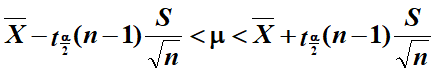

In [3]:
critval <- qt(0.975,df=4)

In [4]:
x1=temp.mean-critval*temp.se
x2=temp.mean+critval*temp.se

In [7]:
cat(x1,'\t',x2,'\n')

19.7872 	 21.64107 


In [10]:
temp.mean+c(-1,1)*qt(p=0.95,df=4)*temp.se  #90 percent

[1] 20.00240 21.42586

In [12]:
temp.mean+c(-1,1)*qt(p=0.995,df=4)*temp.se  #99 percent

[1] 19.17702 22.25124

#### HYPOTHESIS TESTING

##### Testing Means

In [13]:
# One-Sample t-Test

In [14]:
# Say that a consumer calls in with a complaint—over time they have bought and precisely
# weighed the contents of 44 randomly selected 80-gram packs from different
# stores and recorded the weights as follows:
snacks <- c(87.7,80.01,77.28,78.76,81.52,74.2,80.71,79.5,77.87,81.94,80.7,
        82.32,75.78,80.19,83.91,79.4,77.52,77.62,81.4,74.89,82.95,
        73.59,77.92,77.18,79.83,81.23,79.28,78.44,79.01,80.47,76.23,
        78.89,77.14,69.94,78.54,79.7,82.45,77.29,75.52,77.21,75.99,
        81.94,80.41,77.7)

In [15]:
# The customer claims that they’ve been shortchanged
# H0 : μ = 80    H1 : μ < 80

In [16]:
n <- length(snacks)
snack.mean <- mean(snacks)
snack.sd <- sd(snacks)

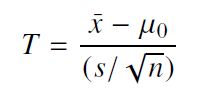

In [19]:
snack.se <- snack.sd/sqrt(n)
snack.T <- (snack.mean-80)/snack.se
snack.T

[1] -2.364419

In [20]:
pvalue = pt(snack.T,df=n-1)
pvalue

[1] 0.01132175

In [21]:
# R Function: t.test

In [ ]:
t.test(x=snacks,mu=80,alternative="less") #alternative决定备择假设 "two.sided" "less" "greater"
# 原假设为μ=80


	One Sample t-test

data:  snacks
t = -2.3644, df = 43, p-value = 0.01132
alternative hypothesis: true mean is less than 80
95 percent confidence interval:
     -Inf 79.68517
sample estimates:
mean of x 
 78.91068 


In [23]:
t.test(x=snacks,mu=80,alternative="two.sided")  # two sided


	One Sample t-test

data:  snacks
t = -2.3644, df = 43, p-value = 0.02264
alternative hypothesis: true mean is not equal to 80
95 percent confidence interval:
 77.98157 79.83980
sample estimates:
mean of x 
 78.91068 


In [24]:
# Two Means

In [25]:
# Unpaired/Independent Samples: Unpooled Variances

In [ ]:
# 在从原始制造商那里收集了 44 包样本之后（将这个样本大小记为 n1），
# 不满的消费者又从一家竞争对手的零食制造商那里随机收集了 31 包标称为 80 克的样本（记为 n2 = 31）。
snacks2 <- c(80.22,79.73,81.1,78.76,82.03,81.66,80.97,81.32,80.12,78.98,
        79.21,81.48,79.86,81.06,77.96,80.73,80.34,80.01,81.82,79.3,
        79.08,79.47,78.98,80.87,82.24,77.22,80.03,79.2,80.95,79.17,81)

In [27]:
snack2.mean <- mean(snacks2)
snack2.sd <- sd(snacks2)
# H0 : μ2 − μ1 = 0   H1 : μ2 − μ1 > 0

In [ ]:
t.test(x=snacks2,y=snacks,alternative="greater",conf.level=0.9)
# 比较 snacks2 的平均重量是否大于 snacks 的平均重量


	Welch Two Sample t-test

data:  snacks2 and snacks
t = 2.4455, df = 60.091, p-value = 0.008706
alternative hypothesis: true difference in means is greater than 0
90 percent confidence interval:
 0.5859714       Inf
sample estimates:
mean of x mean of y 
 80.15710  78.91068 


In [29]:
# Unpaired/Independent Samples: Pooled Variance

In [30]:
# intelligence quotient(IQ)
men <- c(102,87,101,96,107,101,91,85,108,67,85,82)
women <- c(73,81,111,109,143,95,92,120,93,89,119,79,90,126,62,92,77,106,105,111)
t.test(x=men,y=women,alternative="two.sided",conf.level=0.95,var.equal=TRUE)  #var.equal=TRUE


	Two Sample t-test

data:  men and women
t = -0.93758, df = 30, p-value = 0.3559
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -19.016393   7.049727
sample estimates:
mean of x mean of y 
 92.66667  98.65000 


In [31]:
# Paired/Dependent Samples

In [ ]:
# 药物降低静息心率效果的配对样本数据the efficacy of a drug designed to reduce resting heart rates in beats per minute n=16
rate.before <- c(52,66,89,87,89,72,66,65,49,62,70,52,75,63,65,61)
rate.after <- c(51,66,71,73,70,68,60,51,40,57,65,53,64,56,60,59)

In [34]:
rate.d <- rate.after-rate.before
rate.dbar <- mean(rate.d)
rate.sd <- sd(rate.d)

In [35]:
# H0 : μd = 0 H1 : μd < 0

In [37]:
rate.T <- rate.dbar/(rate.sd/sqrt(16))
pt(rate.T,df=15)

[1] 0.000116681

In [ ]:
t.test(x=rate.after,y=rate.before,alternative="less",conf.level=0.95,paired=TRUE)
# paired = TRUE：表示配对样本


	Paired t-test

data:  rate.after and rate.before
t = -4.8011, df = 15, p-value = 0.0001167
alternative hypothesis: true difference in means is less than 0
95 percent confidence interval:
      -Inf -4.721833
sample estimates:
mean of the differences 
                -7.4375 


##### Errors and Power

In [40]:
# Hypothesis Test Errors
# Simulating Type I Errors

In [ ]:
typeI.tester <- function(mu0,sigma,n,alpha,ITERATIONS=10000){
  pvals <- rep(NA,ITERATIONS)
  for(i in 1:ITERATIONS){
    temporary.sample <- rnorm(n=n,mean=mu0,sd=sigma)
    temporary.mean <- mean(temporary.sample)
    temporary.sd <- sd(temporary.sample)
    pvals[i] <- 1-pt((temporary.mean-mu0)/(temporary.sd/sqrt(n)),df=n-1)
  }# 计算单侧t检验的p值，检验H0: 均值=mu0 vs H1: 均值 > mu0
  return(mean(pvals<alpha))# 返回p值小于显著性水平alpha的比例，即模拟估计的一类错误率
}
}

In [42]:
typeI.tester(mu0=0,sigma=1,n=40,alpha=0.05)

[1] 0.0491

In [43]:
typeI.tester(mu0=-4,sigma=0.3,n=60,alpha=0.01)

[1] 0.01

In [44]:
# Simulating Type II Errors

In [ ]:
typeII.tester <- function(mu0,muA,sigma,n,alpha,ITERATIONS=10000){
  pvals <- rep(NA,ITERATIONS)
  for(i in 1:ITERATIONS){
    temporary.sample <- rnorm(n=n,mean=muA,sd=sigma)#mean=muA
    temporary.mean <- mean(temporary.sample)
    temporary.sd <- sd(temporary.sample)
    pvals[i] <- 1-pt((temporary.mean-mu0)/(temporary.sd/sqrt(n)),df=n-1)
  }
  return(mean(pvals>=alpha))
}

In [46]:
typeII.tester(mu0=0,muA=0.5,sigma=1,n=30,alpha=0.05)

[1] 0.1506

In [47]:
typeII.tester(mu0=0,muA=0.5,sigma=1,n=30,alpha=0.01)

[1] 0.3892

In [48]:
typeII.tester(mu0=0,muA=0.5,sigma=1.1,n=30,alpha=0.01)

[1] 0.4743

In [49]:
typeII.tester(mu0=0,muA=0.5,sigma=1.2,n=30,alpha=0.01)

[1] 0.5487

In [50]:
typeII.tester(mu0=0,muA=0.5,sigma=1.2,n=20,alpha=0.01)

[1] 0.7318

In [51]:
typeII.tester(mu0=0,muA=0.5,sigma=1.2,n=40,alpha=0.01)

[1] 0.4069

In [52]:
typeII.tester(mu0=0,muA=0.4,sigma=1.2,n=40,alpha=0.01)

[1] 0.6191

In [53]:
typeII.tester(mu0=0,muA=0.6,sigma=1.2,n=40,alpha=0.01)

[1] 0.2364

In [72]:
1-typeII.tester(mu0=0,muA=0,sigma=1.2,n=40,alpha=0.01) #typeI

[1] 0.0099

In [54]:
# Statistical Power

In [55]:
power.tester <- function(nvec,...){
  nlen <- length(nvec)
  result <- rep(NA,nlen)
  pbar <- txtProgressBar(min=0,max=nlen,style=3)
  for(i in 1:nlen){
    result[i] <- 1-typeII.tester(n=nvec[i],...)
    setTxtProgressBar(pbar,i)
  }
  close(pbar)
  return(result)
}

In [57]:
sample.sizes <- 5:100
pow <- power.tester(nvec=sample.sizes,mu0=0,muA=0.6,sigma=1.2,alpha=0.01,ITERATIONS=5000)
print(pow)

  |======================================================================| 100%
 [1] 0.0638 0.0828 0.0996 0.1294 0.1392 0.1724 0.1858 0.2110 0.2414 0.2658
[11] 0.2808 0.3174 0.3200 0.3556 0.3848 0.4054 0.4252 0.4424 0.4726 0.4970
[21] 0.5056 0.5296 0.5352 0.5668 0.5830 0.6072 0.6178 0.6506 0.6680 0.6846
[31] 0.6944 0.7064 0.7246 0.7438 0.7522 0.7720 0.7896 0.7878 0.8042 0.8116
[41] 0.8118 0.8322 0.8398 0.8468 0.8560 0.8598 0.8760 0.8858 0.8830 0.8926
[51] 0.8988 0.9012 0.9124 0.9182 0.9218 0.9238 0.9346 0.9340 0.9442 0.9472
[61] 0.9484 0.9492 0.9586 0.9626 0.9592 0.9610 0.9630 0.9654 0.9682 0.9710
[71] 0.9702 0.9758 0.9770 0.9820 0.9806 0.9822 0.9816 0.9824 0.9844 0.9880
[81] 0.9848 0.9892 0.9880 0.9858 0.9870 0.9914 0.9922 0.9914 0.9928 0.9936
[91] 0.9930 0.9954 0.9940 0.9946 0.9946 0.9936


In [58]:
minimum.n <- sample.sizes[min(which(pow>=0.8))]
minimum.n

[1] 43

In [59]:
pow2 <- power.tester(nvec=sample.sizes,mu0=0,muA=0.6,sigma=1.2,alpha=0.05,ITERATIONS=5000)
minimum.n2 <- sample.sizes[min(which(pow2>0.8))]
minimum.n2

  |======================================================================| 100%


[1] 27

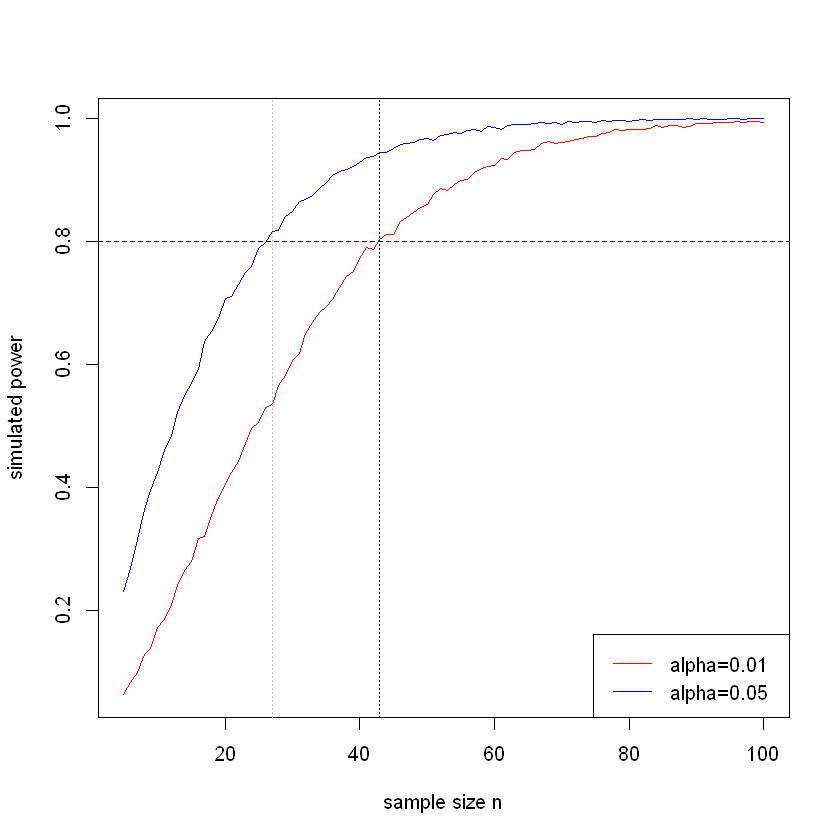

In [67]:
plot(sample.sizes,pow,xlab="sample size n",ylab="simulated power",type='l',col='red')
lines(sample.sizes,pow2,col="blue")
abline(h=0.8,lty=2)
abline(v=c(minimum.n,minimum.n2),lty=3,col=c("black","gray"))
legend("bottomright",legend=c("alpha=0.01","alpha=0.05"),col=c("red","blue"),lty=1)

In [68]:
power.tester1 <- function(nvec,...){
  nlen <- length(nvec)
  result <- rep(NA,nlen)
  pbar <- txtProgressBar(min=0,max=nlen,style=3)
  for(i in 1:nlen){
    result[i] <- 1-typeII.tester(muA=nvec[i],...)
    setTxtProgressBar(pbar,i)
  }
  close(pbar)
  return(result)
}
pow1 <- power.tester1(nvec=seq(0,1,length=20),mu0=0,n=30,sigma=1.2,alpha=0.05,ITERATIONS=5000)
pow2 <- power.tester1(nvec=seq(0,1,length=20),mu0=0,n=30,sigma=1.2,alpha=0.01,ITERATIONS=5000)

  |======================================================================| 100%
  |======================================================================| 100%


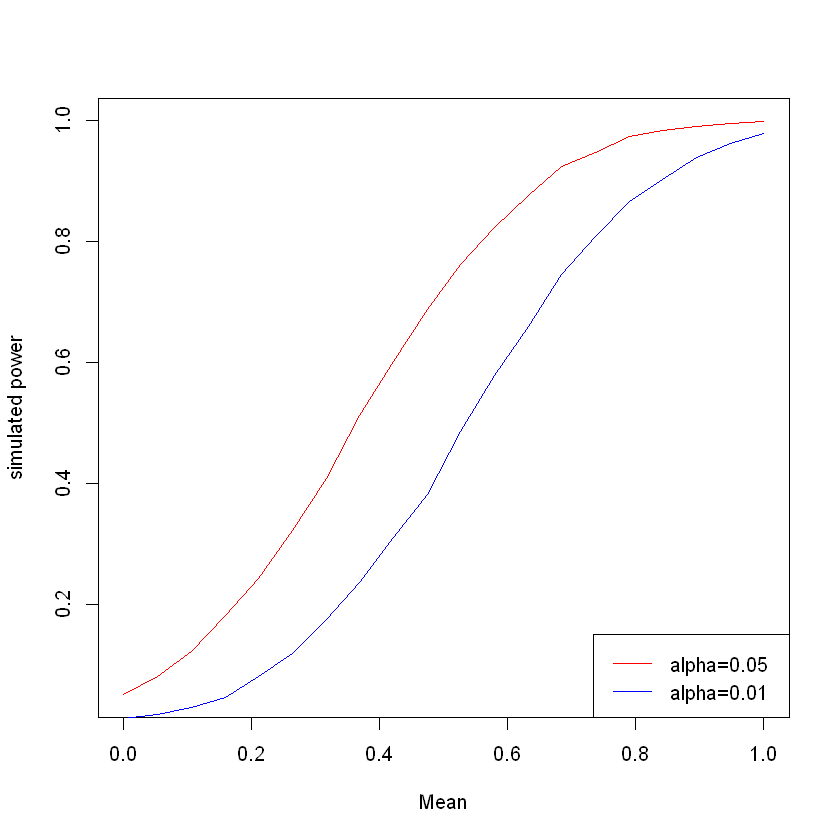

In [73]:
plot(seq(0,1,length=20),pow1,xlab="Mean",ylab="simulated power",type='l',col='red')
lines(seq(0,1,length=20),pow2,col="blue")
legend("bottomright",legend=c("alpha=0.05","alpha=0.01"),col=c("red","blue"),lty=1)

In [74]:
# LINEAR REGRESSION

In [75]:
library("MASS")

In [77]:
head(survey)

Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age
Female,18.5,18.0,Right,R on L,92,Left,Some,Never,173.00,Metric,18.250
Male,19.5,20.5,Left,R on L,104,Left,None,Regul,177.80,Imperial,17.583
Male,18.0,13.3,Right,L on R,87,Neither,None,Occas,NA,NA,16.917
Male,18.8,18.9,Right,R on L,NA,Neither,None,Never,160.00,Metric,20.333
Male,20.0,20.0,Right,Neither,35,Right,Some,Never,165.00,Metric,23.667
Female,18.0,17.7,Right,L on R,64,Right,Some,Never,172.72,Imperial,21.000


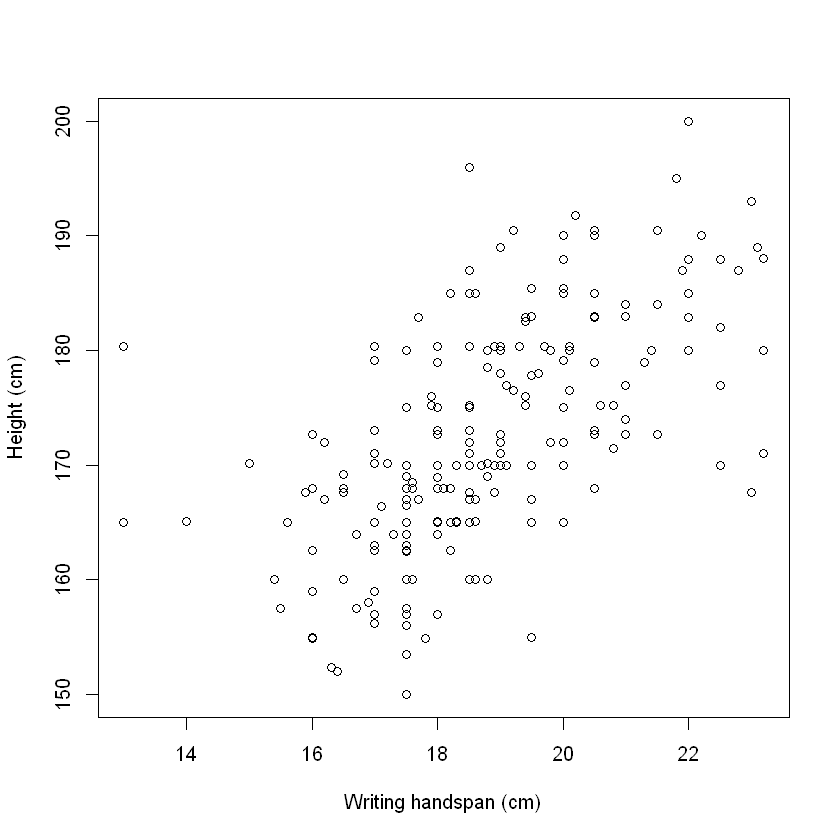

In [ ]:
plot(survey$Height~survey$Wr.Hnd,xlab="Writing handspan (cm)",ylab="Height (cm)")
# plot(y ~ x) plot(x, y)

In [ ]:
cor(survey$Wr.Hnd,survey$Height,use="complete.obs")
# 只用两者都不是缺失值（NA）的观测对来计算相关系数，自动忽略含有缺失值的行。

[1] 0.6009909

In [ ]:
survfit <- lm(Height~Wr.Hnd,data=survey)#线性模型（Linear Model）

In [81]:
survfit


Call:
lm(formula = Height ~ Wr.Hnd, data = survey)

Coefficients:
(Intercept)       Wr.Hnd  
    113.954        3.117  


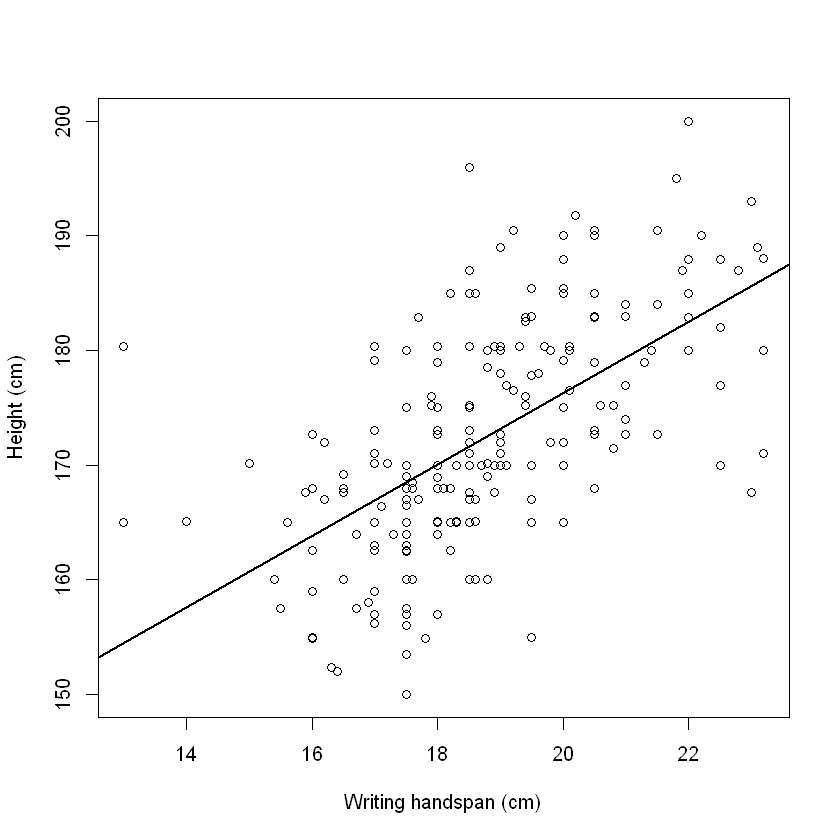

In [83]:
plot(survey$Height~survey$Wr.Hnd,xlab="Writing handspan (cm)",ylab="Height (cm)")
abline(survfit,lwd=2)

In [84]:
summary(survfit)


Call:
lm(formula = Height ~ Wr.Hnd, data = survey)

Residuals:
     Min       1Q   Median       3Q      Max 
-19.7276  -5.0706  -0.8269   4.9473  25.8704 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 113.9536     5.4416   20.94   <2e-16 ***
Wr.Hnd        3.1166     0.2888   10.79   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 7.909 on 206 degrees of freedom
  (29 observations deleted due to missingness)
Multiple R-squared:  0.3612,	Adjusted R-squared:  0.3581 
F-statistic: 116.5 on 1 and 206 DF,  p-value: < 2.2e-16


In [ ]:
xvals <- data.frame(Wr.Hnd=c(14.5,24))
mypred.ci <- predict(survfit,newdata=xvals,interval="confidence",level=0.95)
mypred.ci#predict()：用之前拟合好的线性模型 survfit 对这两个新的 Wr.Hnd 值预测对应的 Height（身高）。

fit,lwr,upr
159.1446,156.4956,161.7936
188.7524,185.5726,191.9323


In [86]:
# Linear Regression Model of Binary Variables

In [87]:
survfit2 <- lm(Height~Sex,data=survey)

In [88]:
summary(survfit2)


Call:
lm(formula = Height ~ Sex, data = survey)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.886  -5.667   1.174   4.358  21.174 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  165.687      0.730  226.98   <2e-16 ***
SexMale       13.139      1.022   12.85   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 7.372 on 206 degrees of freedom
  (29 observations deleted due to missingness)
Multiple R-squared:  0.4449,	Adjusted R-squared:  0.4422 
F-statistic: 165.1 on 1 and 206 DF,  p-value: < 2.2e-16


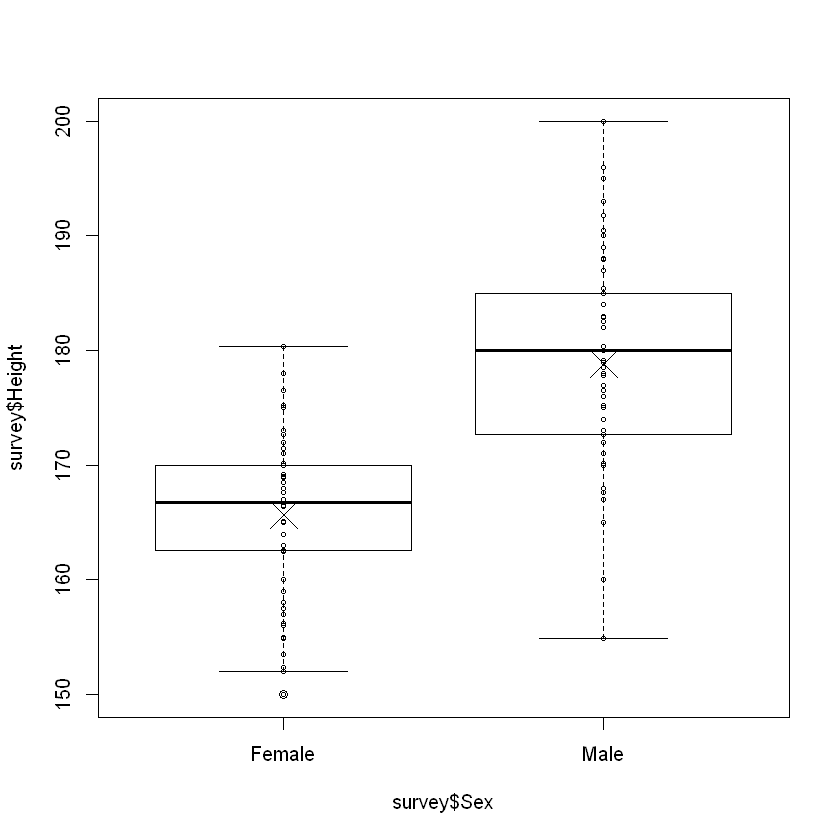

In [90]:
plot(survey$Height~survey$Sex)
points(survey$Height~as.numeric(survey$Sex),cex=0.5)
means.sex <- tapply(survey$Height,INDEX=survey$Sex,FUN=mean,na.rm=TRUE)
points(1:2,means.sex,pch=4,cex=3)

In [91]:
# MULTIPLE LINEAR REGRESSION

In [92]:
demo.data <- data.frame(y=c(1.55,0.42,1.29,0.73,0.76,-1.09,1.41,-0.32),x1=c(1.13,-0.73,0.12,0.52,-0.54,-1.15,0.20,-1.09),x2=c(1,0,1,1,0,1,0,1))
head(demo.data)

y,x1,x2
1.55,1.13,1
0.42,-0.73,0
1.29,0.12,1
0.73,0.52,1
0.76,-0.54,0
-1.09,-1.15,1


In [93]:
demo.fit <- lm(y~x1+x2,data=demo.data)

In [94]:
summary(demo.fit)


Call:
lm(formula = y ~ x1 + x2, data = demo.data)

Residuals:
       1        2        3        4        5        6        7        8 
-0.12473 -0.06429  0.64073 -0.32539  0.08281 -0.44984 -0.01852  0.25924 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept)   1.2255     0.2424   5.055  0.00392 **
x1            1.0153     0.1898   5.348  0.00307 **
x2           -0.6980     0.2987  -2.337  0.06661 . 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4032 on 5 degrees of freedom
Multiple R-squared:  0.8601,	Adjusted R-squared:  0.8042 
F-statistic: 15.37 on 2 and 5 DF,  p-value: 0.007316


In [95]:
survmult <- lm(Height~Wr.Hnd+Sex,data=survey)
summary(survmult)


Call:
lm(formula = Height ~ Wr.Hnd + Sex, data = survey)

Residuals:
     Min       1Q   Median       3Q      Max 
-17.7479  -4.1830   0.7749   4.6665  21.9253 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 137.6870     5.7131  24.100  < 2e-16 ***
Wr.Hnd        1.5944     0.3229   4.937 1.64e-06 ***
SexMale       9.4898     1.2287   7.724 5.00e-13 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6.987 on 204 degrees of freedom
  (30 observations deleted due to missingness)
Multiple R-squared:  0.5062,	Adjusted R-squared:  0.5014 
F-statistic: 104.6 on 2 and 204 DF,  p-value: < 2.2e-16


In [96]:
survmult2 <- lm(Height~Wr.Hnd+Sex+Smoke,data=survey)
summary(survmult2)


Call:
lm(formula = Height ~ Wr.Hnd + Sex + Smoke, data = survey)

Residuals:
     Min       1Q   Median       3Q      Max 
-17.4869  -4.7617   0.7604   4.3691  22.1237 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 137.4056     6.5444  20.996  < 2e-16 ***
Wr.Hnd        1.6042     0.3301   4.860 2.36e-06 ***
SexMale       9.3979     1.2452   7.547 1.51e-12 ***
SmokeNever   -0.0442     2.3135  -0.019    0.985    
SmokeOccas    1.5267     2.8694   0.532    0.595    
SmokeRegul    0.9211     2.9290   0.314    0.753    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 7.023 on 201 degrees of freedom
  (30 observations deleted due to missingness)
Multiple R-squared:  0.5085,	Adjusted R-squared:  0.4962 
F-statistic: 41.59 on 5 and 201 DF,  p-value: < 2.2e-16


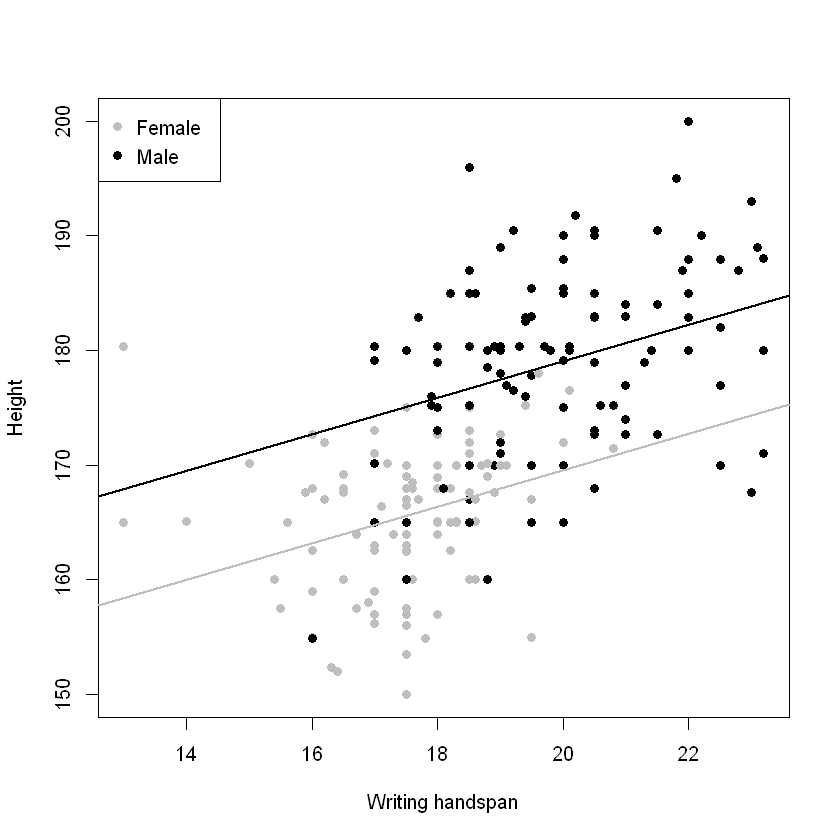

In [97]:
survcoefs <- coef(survmult)
plot(survey$Height~survey$Wr.Hnd,col=c("gray","black")[as.numeric(survey$Sex)],pch=16,xlab="Writing handspan",ylab="Height")
abline(a=survcoefs[1],b=survcoefs[2],col="gray",lwd=2)
abline(a=survcoefs[1]+survcoefs[3],b=survcoefs[2],col="black",lwd=2)
legend("topleft",legend=levels(survey$Sex),col=c("gray","black"),pch=16)